In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [104]:
train_df = pd.read_csv('data1C/train_data_1C.csv')
test_df = pd.read_csv('data1C/test_data_1C.csv')
train_df.head()
test_df.head()

,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,circumplex.arousal_mean_3d_hist,circumplex.valence_mean_3d_hist,mood_std_3d_hist,activity_std_3d_hist,screen_std_3d_hist,mood_change_today_vs_yesterday,activity_change_today_vs_yesterday,screen_change_today_vs_yesterday,day_of_week,is_weekend
0,AS14.01,2014-04-26,0.214249,864.519,2567.857,125.556,27.267,0.000,0.0,46.205,...,-0.200000,0.800000,0.000000,0.000000,0.000000,0.4,0.105188,-6367.454000,5,1
1,AS14.01,2014-04-27,0.030479,1291.314,2431.498,1510.221,0.000,0.000,0.0,1056.684,...,-0.200000,0.900000,0.282843,0.074379,4502.469903,-0.1,-0.183770,784.459001,6,1
2,AS14.01,2014-04-28,0.019675,1312.001,4697.372,1548.438,465.253,0.000,0.0,72.584,...,-0.133333,0.933333,0.208167,0.092205,3472.023414,0.1,-0.010804,5107.268000,0,0
3,AS14.01,2014-04-29,0.102758,1811.833,3834.645,1562.533,0.000,333.305,0.0,40.472,...,-0.333333,0.933333,0.057735,0.109352,3199.270995,-0.6,0.083083,-2934.538001,1,0
4,AS14.01,2014-04-30,0.151051,844.963,3550.618,504.862,375.022,0.000,0.0,185.783,...,-0.266667,0.933333,0.321455,0.045173,2563.085879,0.8,0.048293,-1874.371000,2,0


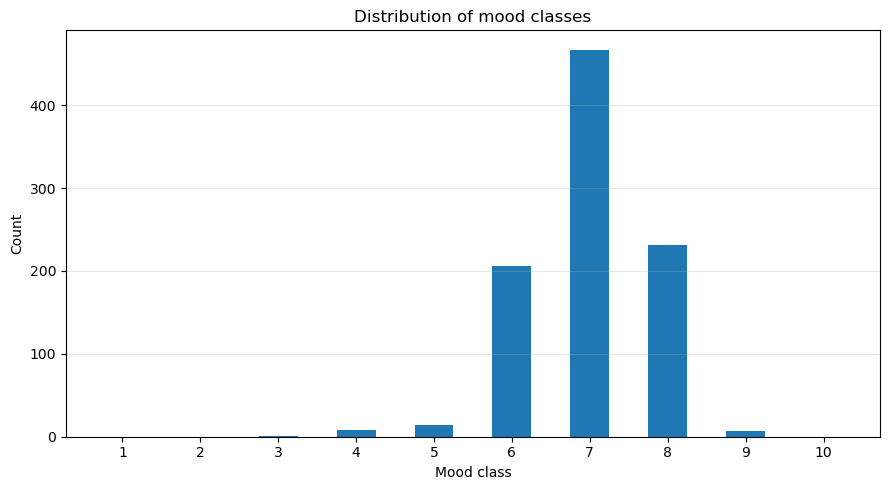

In [105]:
train_df["mood_class"] = train_df["mood"].round().clip(1, 10).astype(int)

counts = train_df["mood_class"].value_counts().sort_index().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(9, 5))
plt.bar(counts.index, counts.values, width=0.5)
plt.title("Distribution of mood classes")
plt.xlabel("Mood class")
plt.ylabel("Count")
plt.xticks(range(1, 11))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [106]:
low  = train_df["mood_next_day"].quantile(0.33)
high = train_df["mood_next_day"].quantile(0.67)

def mood_to_class(x):
    if x <= low:  return 0
    elif x <= high: return 1
    else: return 2
    
train_df["mood_class_next_day"] = train_df["mood_next_day"].apply(mood_to_class)
test_df["mood_class_next_day"] = test_df["mood_next_day"].apply(mood_to_class)

In [107]:
drop_cols = [
    "id",
    "date",
    "next_date",
    "mood_next_day",
    "mood_class_next_day",
    "is_fake",
    "num_nonzero",
    "mood_class"
]

X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])

y_train = train_df["mood_class_next_day"]
y_test = test_df["mood_class_next_day"]

In [108]:
print(X_train.columns.tolist())
print(X_test.columns.tolist())

['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'circumplex.arousal', 'circumplex.valence', 'sms', 'screen', 'mood', 'mood_lag1', 'activity_lag1', 'screen_lag1', 'mood_mean_3d_hist', 'activity_mean_3d_hist', 'screen_mean_3d_hist', 'call_mean_3d_hist', 'sms_mean_3d_hist', 'appCat.builtin_mean_3d_hist', 'appCat.communication_mean_3d_hist', 'appCat.entertainment_mean_3d_hist', 'appCat.finance_mean_3d_hist', 'appCat.game_mean_3d_hist', 'appCat.office_mean_3d_hist', 'appCat.other_mean_3d_hist', 'appCat.social_mean_3d_hist', 'appCat.travel_mean_3d_hist', 'appCat.unknown_mean_3d_hist', 'appCat.utilities_mean_3d_hist', 'appCat.weather_mean_3d_hist', 'circumplex.arousal_mean_3d_hist', 'circumplex.valence_mean_3d_hist', 'mood_std_3d_hist', 'activity_std_3d_hist', 'screen_std_3d_hist', 'mood_change_today_

In [109]:
#scaling all features within the same range, done after splitting into train/test to avoid leaking test statistics into training
#class_weight=balanced penalizes misclassifying the minority classes more heavily, to make sure the SVM doesn´t just learn to predict the majority classes
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(class_weight="balanced"))])

# C : control tradeoff between smooth decision boundary and classifying training points correctly. low c = smoother, more generalizable, high c = fits training data more tightly
# kernel : how the svm maps data to higher dimensions, rbf assumes non-linear relationships, linear works with classes that are linearly separable
# gamma : controls how far the influence of a single training point reaches into the rbf kernel
param_grid = {
    "svm__C" : [0.1, 1, 10],
    "svm__kernel" : ["rbf", "linear"],
    "svm__gamma" : ["scale", "auto"]
}

#gridssearch to find best hyperparams, evaluates each combination using cross-validation. Using GroupKFold to make sure no participant appear in both the fold'set
#train and val set. 
#Using f1 score which is better for unbalanced datasets, computes f1 seperatly for each class and averages them equally. 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(pipe, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
search.fit(X_train, y_train)

print("Best CV f1_macro:", search.best_score_)
print("Best params:", search.best_params_)

Best CV f1_macro: 0.5387375478466494
Best params: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}


GridSearchCV automatically retrains the best model found on the full training set after finding the best parameters.

              precision    recall  f1-score   support

         low       0.61      0.63      0.62        79
      medium       0.49      0.52      0.50        75
        high       0.53      0.47      0.50        74

    accuracy                           0.54       228
   macro avg       0.54      0.54      0.54       228
weighted avg       0.54      0.54      0.54       228



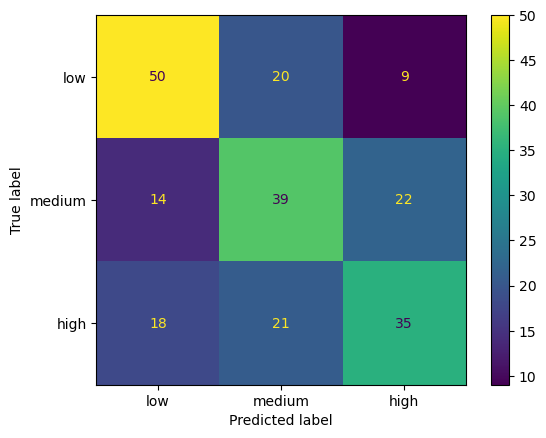

In [110]:

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["low", "medium", "high"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["low", "medium", "high"])
disp.plot()

In [ ]:

# Ordinal-aware metrics
mae_ord = mean_absolute_error(y_test, y_pred)
qwk = cohen_kappa_score(y_test, y_pred, weights="quadratic")

print(f"Ordinal MAE: {mae_ord:.3f}")
print(f"Quadratic weighted kappa: {qwk:.3f}")



Ordinal MAE: 0.575
Quadratic weighted kappa: 0.384
Off-by-one accuracy: 0.882
